# Stock Portfolio Analysis: Risk, Return and Optimisation

**Author:** Abhishek Pandya

This notebook analyses four large US stocks (Apple, Microsoft, IBM and Starbucks) against the S&P 500 index from **January 2007 to March 2016**. That window includes the 2008 financial crisis, which makes it a useful test of how different stocks and portfolios behave under stress.

**Questions:**
1. Which stocks rewarded investors best, after accounting for risk?
2. How badly did each one fall during the financial crisis, and how long did recovery take?
3. How much diversification do these stocks offer each other?
4. What does Modern Portfolio Theory say the "optimal" portfolio is?
5. **Would that optimal portfolio actually have worked if chosen in advance?**

**Data:** daily adjusted closing prices from the public [Plotly datasets repository](https://github.com/plotly/datasets/blob/master/stockdata.csv). `GSPC` is the S&P 500 price index (excludes dividends).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import portfolio_metrics as pm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.options.display.float_format = "{:.3f}".format

RISK_FREE = 0.02  # assumed annual risk-free rate
NAMES = {"AAPL": "Apple", "MSFT": "Microsoft", "IBM": "IBM", "SBUX": "Starbucks", "GSPC": "S&P 500"}

def save(fig, name):
    fig.savefig(f"images/{name}.png", dpi=120, bbox_inches="tight")

## 1. Load and check the data

In [2]:
prices = pm.load_prices("data/stock_prices.csv")
print(f"{len(prices):,} trading days from {prices.index.min():%d %b %Y} to {prices.index.max():%d %b %Y}")
print("Missing values:", prices.isna().sum().sum())
prices.head()

2,306 trading days from 03 Jan 2007 to 01 Mar 2016
Missing values: 0


,MSFT,IBM,SBUX,AAPL,GSPC
Date,,,,,
2007-01-03,23.951,80.518,16.150,11.087,1416.600
2007-01-04,23.911,81.379,16.168,11.333,1418.340
2007-01-05,23.774,80.642,16.099,11.252,1409.710
2007-01-08,24.007,81.867,16.040,11.308,1412.840
2007-01-09,24.031,82.836,15.971,12.247,1412.110


The data is complete with no missing values. Prices are on very different scales (the S&P 500 is in the thousands), so to compare them fairly I rebase every series to show what **$10,000 invested on day one** would have become.

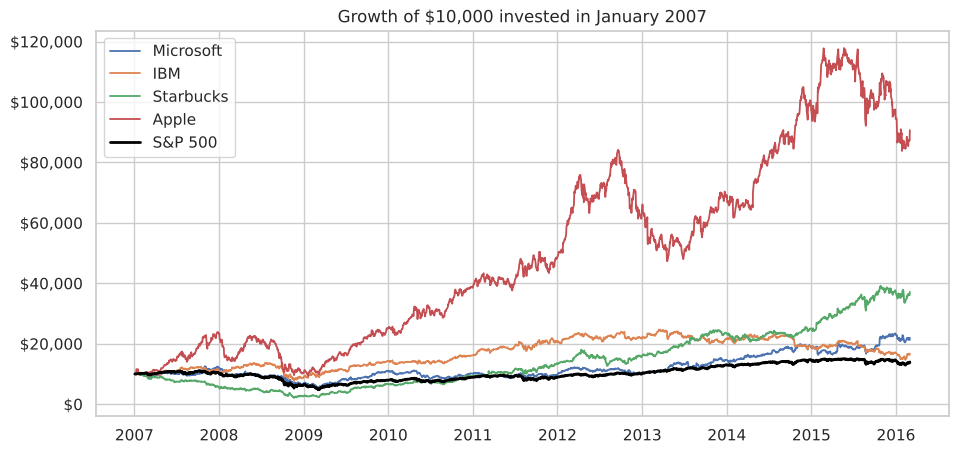

,Final value
Apple,"$90,677"
Starbucks,"$37,177"
Microsoft,"$21,953"
IBM,"$16,688"
S&P 500,"$13,965"


In [3]:
growth = prices / prices.iloc[0] * 10_000

fig, ax = plt.subplots()
for col in growth:
    ax.plot(growth.index, growth[col], label=NAMES[col], lw=2 if col == "GSPC" else 1.3,
            color="black" if col == "GSPC" else None)
ax.set_title("Growth of $10,000 invested in January 2007")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.legend()
save(fig, "growth")
plt.show()

growth.iloc[-1].rename(index=NAMES).sort_values(ascending=False).map("${:,.0f}".format).to_frame("Final value")

Apple dominates: $10,000 grew about nine-fold to over $90,000, helped by the iPhone era. Every individual stock beat the S&P 500 price index over this period, but raw return is only half the story. Next I look at the risk taken to earn it.

## 2. Risk and return metrics

| Metric | Meaning |
|---|---|
| **CAGR** | Compound annual growth rate: the steady yearly return that gives the same end result |
| **Volatility** | Annualised standard deviation of daily returns: how bumpy the ride is |
| **Sharpe ratio** | (Return − risk-free rate) ÷ volatility: return earned per unit of risk |
| **Sortino ratio** | Like Sharpe, but only counts *downside* volatility |
| **Max drawdown** | Worst fall from a previous peak |
| **Beta** | How much the stock moves when the market moves 1% |

In [4]:
summary = pm.summary_table(prices, risk_free=RISK_FREE).rename(index=NAMES)
summary.sort_values("Sharpe", ascending=False).style.format({
    "CAGR": "{:.1%}", "Volatility": "{:.1%}", "Max drawdown": "{:.1%}",
    "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Beta": "{:.2f}",
}).background_gradient(subset=["Sharpe"], cmap="Greens")

,CAGR,Volatility,Sharpe,Sortino,Max drawdown,Beta
Apple,27.2%,33.8%,0.82,1.20,-60.9%,0.96
Starbucks,15.4%,33.8%,0.53,0.81,-80.2%,1.06
Microsoft,9.0%,29.0%,0.37,0.55,-57.9%,0.95
IBM,5.8%,22.9%,0.27,0.39,-44.3%,0.76
S&P 500,3.7%,21.6%,0.18,0.26,-56.8%,1.00


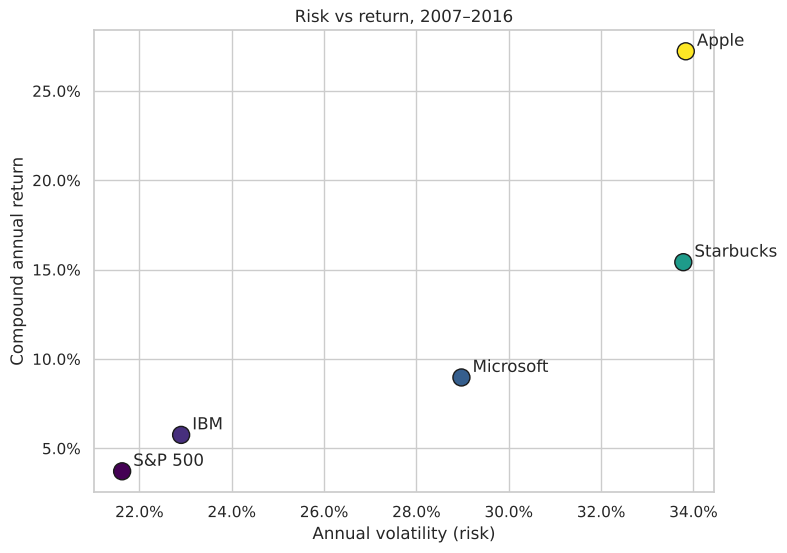

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(summary["Volatility"], summary["CAGR"], s=150, c=summary["Sharpe"], cmap="viridis", edgecolor="k")
for name, row in summary.iterrows():
    ax.annotate(name, (row["Volatility"], row["CAGR"]), xytext=(8, 4), textcoords="offset points")
ax.set_xlabel("Annual volatility (risk)")
ax.set_ylabel("Compound annual return")
ax.set_title("Risk vs return, 2007–2016")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
save(fig, "risk_return")
plt.show()

**Findings:**
- **Apple** had the best risk-adjusted return by a wide margin (Sharpe ≈ 0.82): the same volatility as Starbucks but far more return.
- **Starbucks** had the deepest crash of any asset (about −80% at the bottom), yet still delivered the second-highest return. A high Sharpe ratio does not protect you from a painful drawdown.
- **IBM** was the most defensive stock (lowest volatility, lowest beta at ≈ 0.76, smallest drawdown) but also the lowest return.
- All betas are close to 1, so these stocks largely moved with the market.

## 3. Drawdowns: the financial crisis

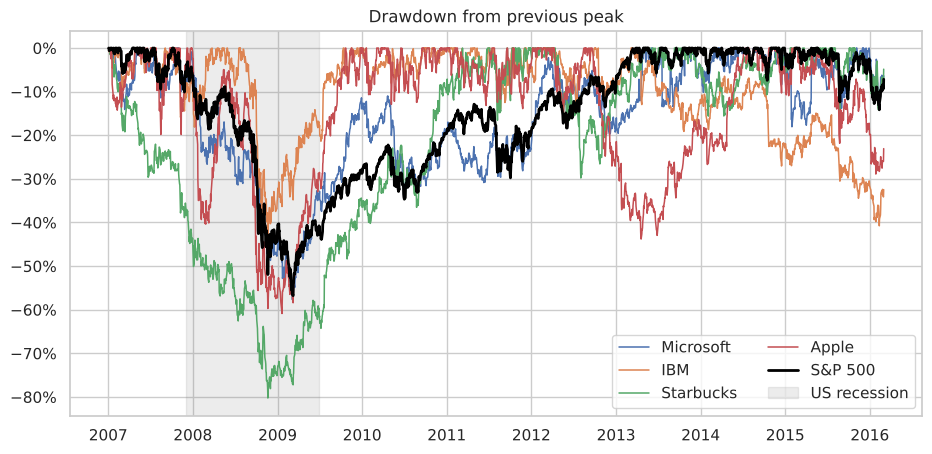

In [6]:
dd = pm.drawdown(prices).rename(columns=NAMES)

fig, ax = plt.subplots()
for col in dd:
    ax.plot(dd.index, dd[col], label=col, lw=2 if col == "S&P 500" else 1.1,
            color="black" if col == "S&P 500" else None)
ax.axvspan(pd.Timestamp("2007-12-01"), pd.Timestamp("2009-06-30"), color="grey", alpha=0.15, label="US recession")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Drawdown from previous peak")
ax.legend(loc="lower right", ncol=2)
save(fig, "drawdowns")
plt.show()

In [7]:
def recovery_stats(series):
    peak_date = series[: series.idxmin()].idxmax()
    trough_date = series.idxmin()
    recovered = series[trough_date:][series[trough_date:] >= series[peak_date]]
    recovery_date = recovered.index[0] if len(recovered) else None
    return pd.Series({
        "Peak": peak_date.date(),
        "Trough": trough_date.date(),
        "Fall": series.min() / series[peak_date] - 1,
        "Recovered": recovery_date.date() if recovery_date else "Not by Mar 2016",
        "Days underwater": (recovery_date - peak_date).days if recovery_date else None,
    })

prices.rename(columns=NAMES).apply(recovery_stats).T

,Peak,Trough,Fall,Recovered,Days underwater
Microsoft,2007-11-01,2009-03-09,-0.579,2013-04-30,2007
IBM,2008-07-22,2008-11-20,-0.443,2009-10-12,447
Starbucks,2007-01-17,2008-11-20,-0.802,2011-03-10,1513
Apple,2007-12-28,2009-01-20,-0.609,2009-10-21,663
S&P 500,2007-10-09,2009-03-09,-0.568,2013-03-28,1997


The S&P 500 price index took over five years to regain its 2007 peak. Apple fell further than the index but recovered much faster, while Starbucks' −80% collapse shows why concentration in a single stock is risky, even one that did well over the full period.

## 4. Correlation and diversification

Diversification only helps if assets don't all move together. Correlation of daily returns measures this (1 = move in lockstep, 0 = unrelated).

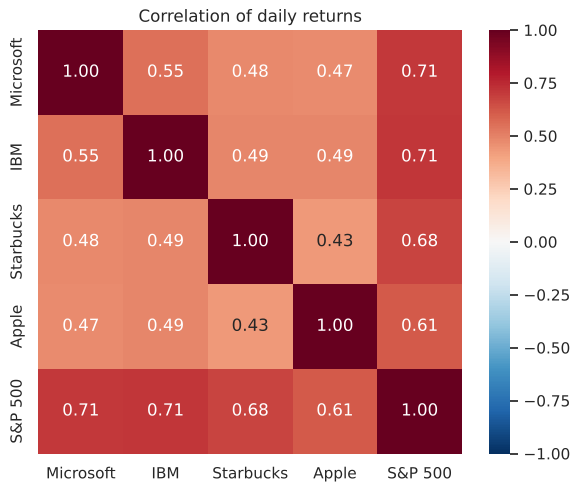

In [8]:
returns = pm.daily_returns(prices)
corr = returns.rename(columns=NAMES).corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation of daily returns")
save(fig, "correlation")
plt.show()

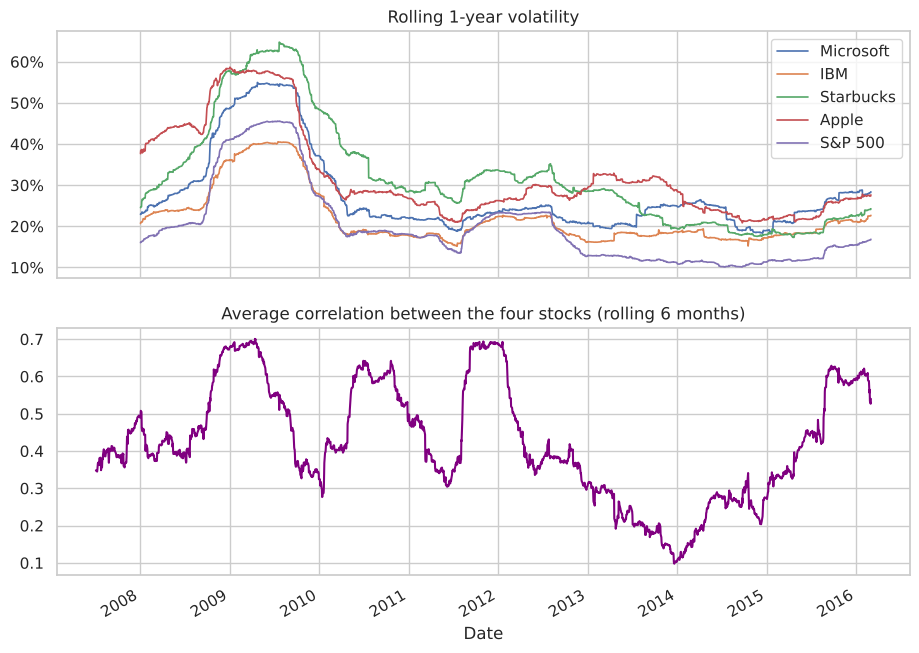

In [9]:
rolling_vol = returns.rolling(252).std().mul(np.sqrt(252)).rename(columns=NAMES)
stock_cols = [c for c in returns.columns if c != "GSPC"]
avg_pair_corr = (
    returns[stock_cols].rolling(126).corr()
    .groupby(level=0).apply(lambda m: m.values[np.triu_indices(len(stock_cols), 1)].mean())
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
rolling_vol.plot(ax=ax1, lw=1.2)
ax1.set_title("Rolling 1-year volatility")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1))
avg_pair_corr.plot(ax=ax2, color="purple")
ax2.set_title("Average correlation between the four stocks (rolling 6 months)")
save(fig, "rolling_risk")
plt.show()

Correlations between the stocks are moderate (0.43–0.55), so combining them should reduce risk. However, the rolling chart shows an important real-world pattern: **correlations and volatility both spike during crises**. Diversification is weakest exactly when you need it most.

## 5. Portfolio optimisation (Modern Portfolio Theory)

Now I build portfolios from the four stocks (long-only, fully invested, no leverage). First, 10,000 random weightings to map out what's possible, then numerical optimisation (`scipy.optimize`) to find:
- the **maximum Sharpe ratio** portfolio (best risk-adjusted return)
- the **minimum volatility** portfolio (lowest risk)
- the **efficient frontier**: the lowest-risk portfolio for each level of return

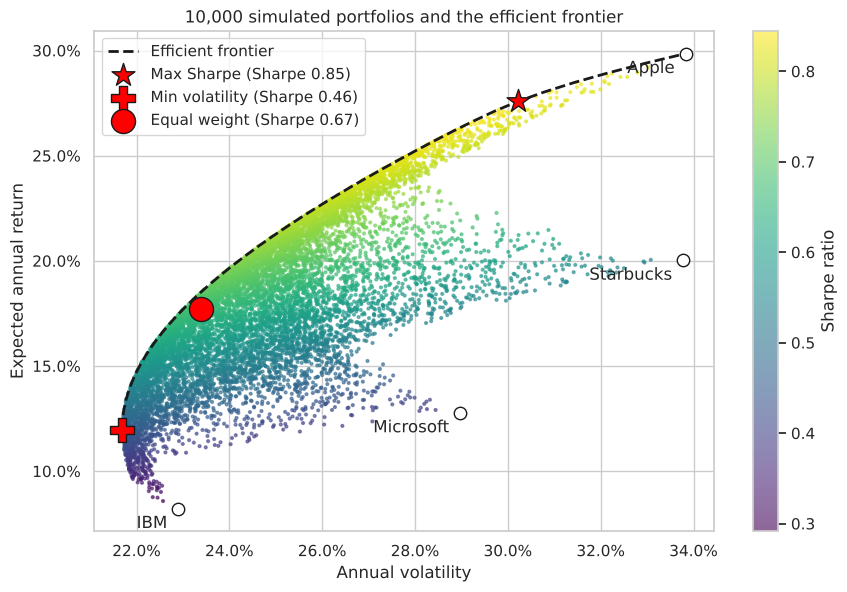

,Max Sharpe,Min volatility,Equal weight
Microsoft,0.0%,18.3%,25.0%
IBM,0.0%,64.4%,25.0%
Starbucks,23.1%,8.4%,25.0%
Apple,76.9%,8.9%,25.0%


In [10]:
stock_returns = returns[stock_cols]
sims, sim_weights = pm.random_portfolios(stock_returns, n=10_000, risk_free=RISK_FREE)
frontier = pm.efficient_frontier(stock_returns)

w_sharpe = pm.max_sharpe_weights(stock_returns, RISK_FREE)
w_minvol = pm.min_volatility_weights(stock_returns)
w_equal = pd.Series(0.25, index=stock_cols)

mean, cov = stock_returns.mean().values, stock_returns.cov().values
portfolios = {"Max Sharpe": w_sharpe, "Min volatility": w_minvol, "Equal weight": w_equal}
perf = {k: pm.portfolio_performance(w.values, mean, cov, RISK_FREE) for k, w in portfolios.items()}

fig, ax = plt.subplots(figsize=(10, 6.5))
sc = ax.scatter(sims["Volatility"], sims["Return"], c=sims["Sharpe"], cmap="viridis", s=4, alpha=0.6)
fig.colorbar(sc, label="Sharpe ratio")
ax.plot(frontier["Volatility"], frontier["Return"], "k--", lw=2, label="Efficient frontier")
for (name, (r, v, s)), marker in zip(perf.items(), ["*", "P", "o"]):
    ax.scatter(v, r, marker=marker, s=300, edgecolor="k", color="red", label=f"{name} (Sharpe {s:.2f})", zorder=3)
for t in stock_cols:
    v, r = stock_returns[t].std() * np.sqrt(252), stock_returns[t].mean() * 252
    ax.scatter(v, r, color="white", edgecolor="k", s=80, zorder=3)
    ax.annotate(NAMES[t], (v, r), xytext=(-8, -14), textcoords="offset points", ha="right")
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Expected annual return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("10,000 simulated portfolios and the efficient frontier")
ax.legend(loc="upper left")
save(fig, "efficient_frontier")
plt.show()

pd.DataFrame(portfolios).rename(index=NAMES).style.format("{:.1%}")

Using the full 2007–2016 history, the maximum-Sharpe portfolio puts about **77% in Apple and 23% in Starbucks**, and nothing in Microsoft or IBM. The minimum-volatility portfolio is mostly IBM.

But there's a catch: these weights were chosen **knowing how the next nine years would turn out**. No real investor in 2007 knew Apple would be the decade's winner. This is *look-ahead bias*.

## 6. The real test: out-of-sample backtest

To make it honest, I split the data:
- **Training period (2007–2012):** choose portfolio weights using only this data
- **Test period (2013–Mar 2016):** see how those weights actually performed on data they never saw

I compare against two simple benchmarks that need no forecasting: an equal-weight portfolio and the S&P 500.

Weights chosen using 2007–2012 data only:


,Max Sharpe (trained 2007–12),Min volatility (trained 2007–12),Equal weight
Microsoft,0.0%,18.4%,25.0%
IBM,9.8%,73.1%,25.0%
Starbucks,0.0%,3.3%,25.0%
Apple,90.2%,5.1%,25.0%


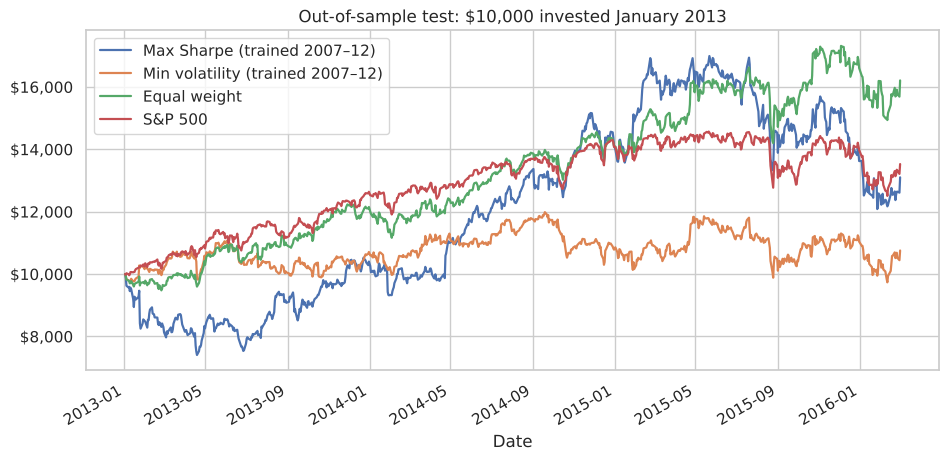

,Final value,CAGR,Volatility,Sharpe,Sortino,Max drawdown,Beta
Max Sharpe (trained 2007–12),"$13,102",8.9%,24.6%,0.39,0.55,-28.9%,0.96
Min volatility (trained 2007–12),"$10,756",2.3%,17.4%,0.10,0.15,-18.8%,0.96
Equal weight,"$16,210",16.5%,16.9%,0.87,1.27,-14.6%,1.02
S&P 500,"$13,528",10.0%,13.3%,0.64,0.90,-14.2%,1.00


In [11]:
train = prices.loc[:"2012-12-31", stock_cols]
test = prices.loc["2013-01-01":]

train_returns = pm.daily_returns(train)
trained = {
    "Max Sharpe (trained 2007–12)": pm.max_sharpe_weights(train_returns, RISK_FREE),
    "Min volatility (trained 2007–12)": pm.min_volatility_weights(train_returns),
    "Equal weight": w_equal,
}
print("Weights chosen using 2007–2012 data only:")
display(pd.DataFrame(trained).rename(index=NAMES).style.format("{:.1%}"))

values = pd.DataFrame({name: pm.backtest(test, w) for name, w in trained.items()})
values["S&P 500"] = test["GSPC"] / test["GSPC"].iloc[0] * 10_000

fig, ax = plt.subplots()
values.plot(ax=ax, lw=1.6)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Out-of-sample test: $10,000 invested January 2013")
save(fig, "backtest")
plt.show()

results = pm.summary_table(values.assign(GSPC=test["GSPC"]), risk_free=RISK_FREE).drop(index="GSPC")
results.insert(0, "Final value", values.iloc[-1])
results.style.format({
    "Final value": "${:,.0f}", "CAGR": "{:.1%}", "Volatility": "{:.1%}", "Max drawdown": "{:.1%}",
    "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Beta": "{:.2f}",
})

In [12]:
test_summary = pm.summary_table(test, risk_free=RISK_FREE).rename(index=NAMES)
test_summary[["CAGR", "Volatility", "Sharpe"]].style.format({"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}"})

,CAGR,Volatility,Sharpe
Microsoft,26.2%,24.8%,0.98
IBM,-8.9%,19.6%,-0.48
Starbucks,29.8%,20.9%,1.26
Apple,10.5%,26.3%,0.44
S&P 500,10.0%,13.3%,0.64


**This is the key result.** The "optimal" portfolio trained on 2007–2012 put about 90% into Apple, the past winner. In 2013–2016, leadership rotated: Starbucks and Microsoft surged, Apple slowed and IBM fell. So:

- The **equal-weight portfolio was the clear winner**, with the highest return, highest Sharpe ratio and smallest drawdown of the three portfolios. It also beat the S&P 500 on both return and Sharpe ratio.
- The **max-Sharpe portfolio** underperformed both equal weight and the S&P 500 on a risk-adjusted basis.
- The **min-volatility portfolio** was dragged down by its heavy IBM weighting and barely grew at all.

Mean-variance optimisation is very sensitive to estimated *expected returns*, and past returns are a poor forecast of future returns. The optimiser treats a historical winning streak as a permanent feature and concentrates the portfolio in it.

## 7. Conclusions

1. **Apple was the standout stock of 2007–2016** on both raw and risk-adjusted return, but even it fell about 60% in the crisis.
2. **High long-run return can hide extreme risk.** Starbucks was the second-best performer yet lost about 80% at its worst.
3. **Diversification helps, but less in a crisis**, because correlations rise when markets fall.
4. **In-sample optimisation is misleading.** A portfolio chosen with hindsight looks brilliant, but chosen in advance it lost to a naive equal-weight split. This matches the academic finding (DeMiguel, Garlappi & Uppal, 2009) that 1/N portfolios are hard to beat out of sample.

### Limitations and next steps
- Only four large US stocks, all of which survived. Survivorship bias flatters the results.
- The S&P 500 series excludes dividends, so the index is understated by about 2% a year.
- No transaction costs, taxes or rebalancing are modelled; the backtest is buy-and-hold.
- A constant 2% risk-free rate is assumed.
- **Extensions:** rolling walk-forward optimisation, shrinkage estimators for the covariance matrix (Ledoit–Wolf), risk-parity weighting, and Value-at-Risk / CVaR analysis.